In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import time
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../Weather_Merged_CSVs/Paddy-2015-2019.csv')
df['Price Date'] = pd.to_datetime(df['Price Date'])
df.set_index('Price Date', inplace=True)
df.sort_index(inplace=True)

In [3]:
df['day_of_year'] = df.index.dayofyear
df['week_of_year'] = df.index.isocalendar().week.astype(int)
df['month'] = df.index.month

In [4]:
categorical_cols = ['District Name', 'Market Name', 'Commodity', 'Variety', 'Grade']
for col in categorical_cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])

In [5]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)
df_scaled = pd.DataFrame(scaled_data, columns=df.columns)
target_column = 'Modal Price (Rs./Quintal)'

In [6]:
n_steps = 1000
batch_size = 64 

In [7]:
def create_sequences(data, n_steps, target_col):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data.iloc[i:(i + n_steps)].values)
        y.append(data.iloc[i + n_steps][target_col])
    return np.array(X), np.array(y).reshape(-1, 1)

In [8]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout_prob):
        super(GRUModel, self).__init__()
        # 3. Use a single GRU layer as per the paper's architecture
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout_prob if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout_prob) # Add dropout layer separately
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.dropout(out[:, -1, :]) # Apply dropout to the output of the last time step
        out = self.fc(out)
        return out

In [9]:
print(f"Applying research findings: n_steps={n_steps}, batch_size={batch_size}")
start_time = time.time()

Applying research findings: n_steps=1000, batch_size=64


In [10]:
X, y = create_sequences(df_scaled, n_steps, target_column)
split = int(0.8 * len(X)) #
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).float()
X_test_tensor = torch.from_numpy(X_test).float()
y_test_tensor = torch.from_numpy(y_test).float()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_size = X_train.shape[2]

In [12]:
model = GRUModel(
    input_size=input_size,
    hidden_size=128,
    num_layers=1,
    output_size=1,
    dropout_prob=0.2
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 50

In [13]:
print("Training model with new parameters...")
for epoch in range(num_epochs):
    model.train()
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}')

Training model with new parameters...
Epoch [10/50], Loss: 0.002222
Epoch [20/50], Loss: 0.002040
Epoch [30/50], Loss: 0.002672
Epoch [40/50], Loss: 0.001057
Epoch [50/50], Loss: 0.002074


In [14]:
print("Evaluating the model in batches to conserve memory...")
model.eval()
all_predictions = [] # Create a list to store predictions from each batch

# Use torch.no_grad() to disable gradient calculation for efficiency
with torch.no_grad():
    # Loop through the test_loader, which was created with a manageable batch_size
    # We only need the input (batch_X) from the loader, not the labels (_)
    for batch_X, _ in test_loader:
        
        # Move the current small batch to the GPU
        batch_X = batch_X.to(device)
        
        # Get the model's output for this batch
        outputs = model(batch_X)
        
        # Move the predictions back to the CPU and append to our list
        all_predictions.append(outputs.cpu().numpy())

# After the loop, concatenate the predictions from all batches into a single NumPy array
predictions = np.concatenate(all_predictions)

Evaluating the model in batches to conserve memory...


In [15]:
price_col_index = df_scaled.columns.get_loc(target_column)
dummy_pred = np.zeros((len(predictions), df_scaled.shape[1]))
dummy_pred[:, price_col_index] = predictions.flatten()
inversed_predictions = scaler.inverse_transform(dummy_pred)[:, price_col_index]

dummy_actual = np.zeros((len(y_test), df_scaled.shape[1]))
dummy_actual[:, price_col_index] = y_test.flatten()
inversed_actual = scaler.inverse_transform(dummy_actual)[:, price_col_index]

rmse = np.sqrt(mean_squared_error(inversed_actual, inversed_predictions))
mean_actual_price = np.mean(inversed_actual)
nrmse = rmse / mean_actual_price if mean_actual_price != 0 else 0

end_time = time.time()
print("\n" + "="*50)
print("Final Evaluation Results:")
print(f"RMSE: {rmse:.2f} Rs./Quintal")
print(f"nRMSE: {nrmse * 100:.2f}%")
print(f"Total Time: {end_time - start_time:.2f}s")
print("="*50)


Final Evaluation Results:
RMSE: 311.49 Rs./Quintal
nRMSE: 20.31%
Total Time: 330.00s


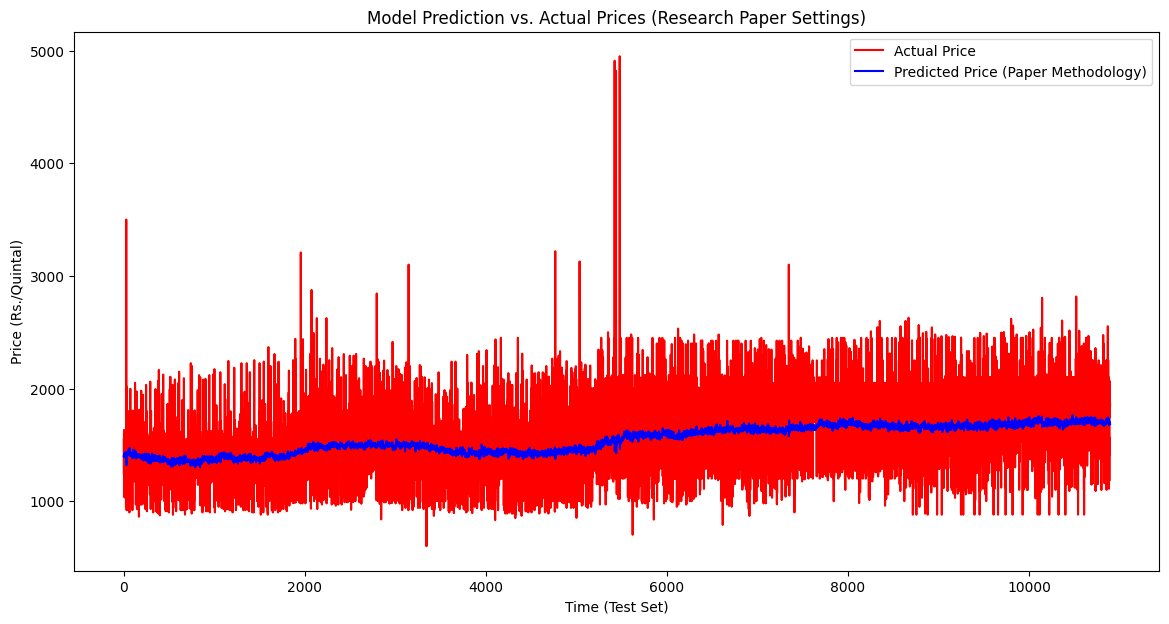

In [16]:
plt.figure(figsize=(14, 7))
plt.plot(inversed_actual, color='red', label='Actual Price')
plt.plot(inversed_predictions, color='blue', label='Predicted Price (Paper Methodology)')
plt.title('Model Prediction vs. Actual Prices (Research Paper Settings)')
plt.xlabel('Time (Test Set)')
plt.ylabel('Price (Rs./Quintal)')
plt.legend()